# ECG Signal Processing & Biometric Identification

Extract **fiducial** and **non-fiducial** features from ECG signals to identify an unknown test signal.

---

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import dct
from scipy.stats import pearsonr
import pywt

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Load the ECG Signals

Each file has two tab-separated columns (23040 samples).  

In [2]:
# ── Load raw signals ──────────────────────────────────────────────────
# Each file has two columns separated by a tab.

ecg_ali_raw      = np.loadtxt('ECG_Ali.txt',      dtype=float)
ecg_mohamed_raw  = np.loadtxt('ECG_Mohamed.txt',  dtype=float)

ecg_ali     = ecg_ali_raw[:, 1]
ecg_mohamed = ecg_mohamed_raw[:, 1]

print(f"ECG_Ali     : {ecg_ali.shape[0]} samples")
print(f"ECG_Mohamed : {ecg_mohamed.shape[0]} samples")

ECG_Ali     : 23040 samples
ECG_Mohamed : 23040 samples


### Preprocessing: Band-Pass Filter

**Why:** Raw ECG has baseline wander (<0.5 Hz) and high-freq noise (muscle/power-line).  
**Method:** 4th-order Butterworth band-pass (0.5–40 Hz), zero-phase (`filtfilt`).  
**Params:** fs=250 Hz, order=4 (good roll-off without ringing).

In [3]:
FS = 250       # Sampling freq (Hz) — MIT-BIH standard
LOWCUT  = 0.5   # Removes baseline wander
HIGHCUT = 40.0  # Removes high-freq noise
ORDER   = 4     # Good trade-off: sharp roll-off, minimal ringing

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    """Zero-phase Butterworth band-pass filter."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)  # filtfilt = zero phase delay

ecg_ali_filt     = bandpass_filter(ecg_ali,     LOWCUT, HIGHCUT, FS, ORDER)
ecg_mohamed_filt = bandpass_filter(ecg_mohamed, LOWCUT, HIGHCUT, FS, ORDER)

print("Band-pass filtering complete.")

Band-pass filtering complete.


### Check for DC Offset After Filtering

Before proceeding, we visualize the filtered signals to determine if any residual DC component remains and whether DC removal is necessary.

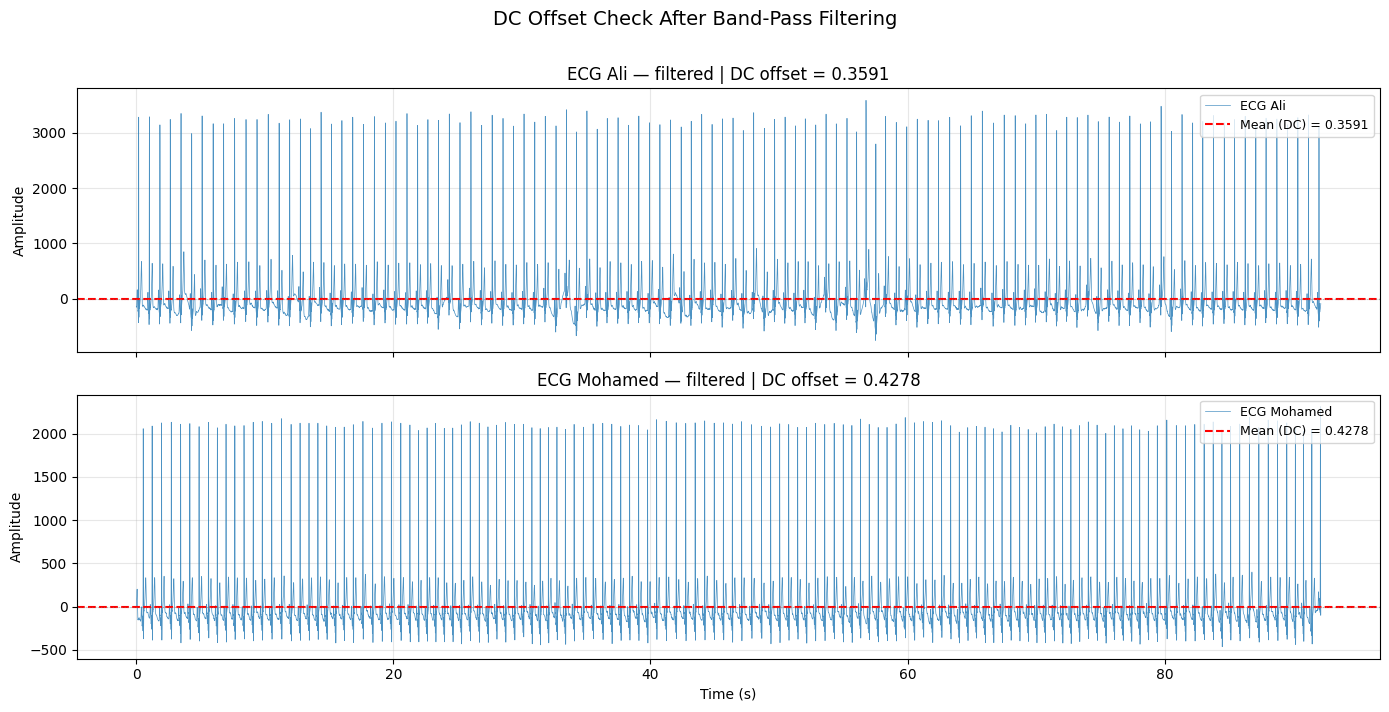

DC offset summary after band-pass filtering:
  ECG Ali        : mean = +0.359142  (DC removal NOT needed)
  ECG Mohamed    : mean = +0.427793  (DC removal NOT needed)


In [4]:
# ── Check DC offset in filtered signals ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

signals_filt = [ecg_ali_filt, ecg_mohamed_filt]
labels = ["ECG Ali", "ECG Mohamed"]

for ax, sig, label in zip(axes, signals_filt, labels):
    t = np.arange(len(sig)) / FS
    mean_val = np.mean(sig)
    ax.plot(t, sig, linewidth=0.5, alpha=0.8, label=label)
    ax.axhline(y=mean_val, color="red", linestyle="--", linewidth=1.5,
               label=f"Mean (DC) = {mean_val:.4f}")
    ax.axhline(y=0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.set_title(f"{label} — filtered | DC offset = {mean_val:.4f}", fontsize=12)
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.suptitle("DC Offset Check After Band-Pass Filtering", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print summary
print("DC offset summary after band-pass filtering:")
for sig, label in zip(signals_filt, labels):
    m = np.mean(sig)
    print(f"  {label:15s}: mean = {m:+.6f}  (DC removal {'recommended' if abs(m) > 0.01 * np.std(sig) else 'NOT needed'})")


### Visualize Filtered Signals (2-second window)

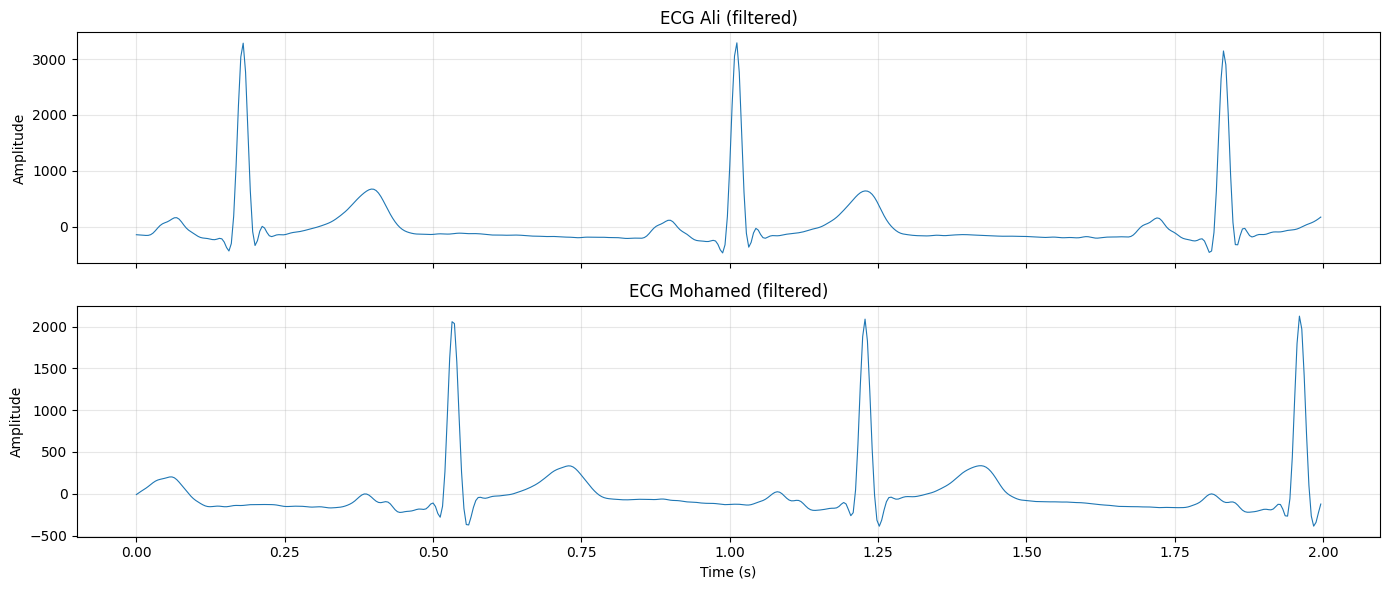

In [5]:
# ── Plot the first 2 seconds ─────────────────────────────────────────
window = int(2 * FS)
time_axis = np.arange(window) / FS  # time in seconds

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

signals = [ecg_ali_filt, ecg_mohamed_filt]
titles  = ['ECG Ali (filtered)', 'ECG Mohamed (filtered)']

for ax, sig, title in zip(axes, signals, titles):
    ax.plot(time_axis, sig[:window], linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


---
# Fiducial Feature Detection (QRS Complex)

**Why fiducial?** QRS landmarks (Q, R, S) are unique per person — intervals and slopes form a biometric fingerprint.

**Detection strategy:**
1. R peaks via `find_peaks` (min distance 200ms ≈ 72 samples → prevents double-detection)
2. Q = local min in 80ms window before R
3. S = local min in 80ms window after R

In [6]:
def detect_qrs_points(signal, fs=250):
    """Detect Q, R, S points in an ECG signal."""
    # R peaks: min 200ms apart (avoids double-detection), adaptive height threshold
    min_distance = int(0.2 * fs)
    threshold = np.mean(signal) + 0.5 * np.std(signal)
    r_peaks, _ = find_peaks(signal, distance=min_distance, height=threshold)

    # Q/S: search 80ms windows around each R (captures typical QRS width)
    q_win = s_win = int(0.08 * fs)
    q_points, s_points, valid_r = [], [], []

    for r in r_peaks:
        q_start = max(0, r - q_win)
        s_end = min(len(signal), r + s_win)
        if q_start >= r or r >= s_end:
            continue
        q_points.append(q_start + np.argmin(signal[q_start:r]))
        s_points.append(r + np.argmin(signal[r:s_end]))
        valid_r.append(r)

    return np.array(q_points), np.array(valid_r), np.array(s_points)

In [7]:
# ── Detect QRS points for all three signals ──────────────────────────
q_ali, r_ali, s_ali          = detect_qrs_points(ecg_ali_filt, FS)
q_mohamed, r_mohamed, s_mohamed = detect_qrs_points(ecg_mohamed_filt, FS)

print(f"ECG_Ali     → {len(r_ali)} beats detected")
print(f"ECG_Mohamed → {len(r_mohamed)} beats detected")


ECG_Ali     → 225 beats detected
ECG_Mohamed → 162 beats detected


### Visualize QRS Detection (first 3 seconds)

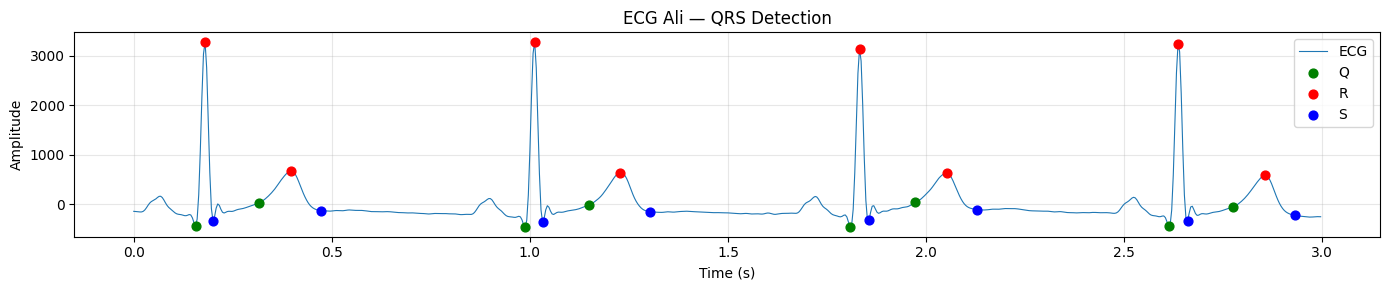

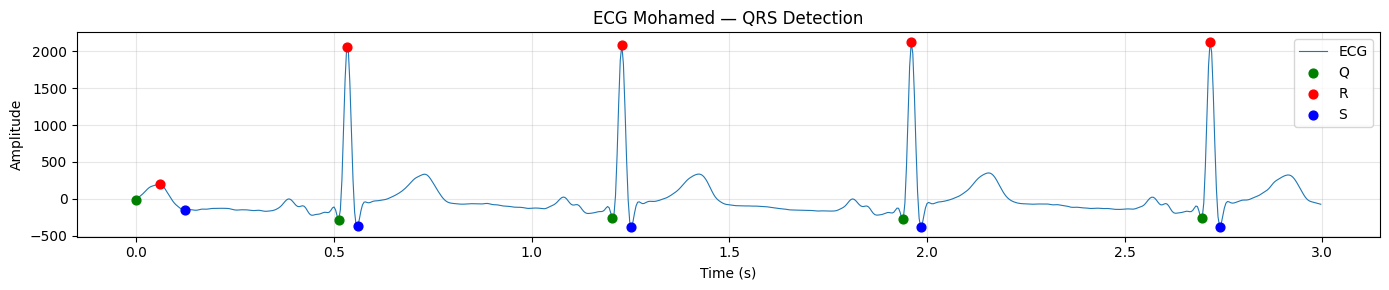

In [8]:
def plot_qrs(signal, q, r, s, title, fs=250, duration=3):
    """Plot ECG with Q/R/S markers."""
    n = int(duration * fs)
    t = np.arange(n) / fs
    plt.figure(figsize=(14, 3))
    plt.plot(t, signal[:n], linewidth=0.8, label='ECG')
    for pts, c, lbl in [(q,'green','Q'), (r,'red','R'), (s,'blue','S')]:
        mask = pts < n
        plt.scatter(pts[mask]/fs, signal[pts[mask]], c=c, s=40, zorder=5, label=lbl)
    plt.title(title); plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_qrs(ecg_ali_filt,     q_ali,     r_ali,     s_ali,     "ECG Ali — QRS Detection",     FS)
plot_qrs(ecg_mohamed_filt, q_mohamed, r_mohamed, s_mohamed, "ECG Mohamed — QRS Detection", FS)


### Fiducial Features

Per-beat: **QR interval**, **RS interval**, **QS slope**.  
Summarised as mean ± std → compact biometric fingerprint.

In [9]:
def compute_fiducial_features(signal, q, r, s, fs=250):
    """Compute mean/std of QR interval, RS interval, and QS slope."""
    qr = r - q
    rs = s - r
    qs_slope = (signal[s] - signal[q]) / (s - q + 1e-9)
    return {
        'QR_interval_mean': np.mean(qr), 'QR_interval_std': np.std(qr),
        'RS_interval_mean': np.mean(rs), 'RS_interval_std': np.std(rs),
        'QS_slope_mean': np.mean(qs_slope), 'QS_slope_std': np.std(qs_slope),
    }, pd.DataFrame({'QR_interval': qr, 'RS_interval': rs, 'QS_slope': qs_slope})

In [10]:
# ── Calculate fiducial features for each signal ──────────────────────
fid_ali,     beats_ali     = compute_fiducial_features(ecg_ali_filt,     q_ali,     r_ali,     s_ali,     FS)
fid_mohamed, beats_mohamed = compute_fiducial_features(ecg_mohamed_filt, q_mohamed, r_mohamed, s_mohamed, FS)

# Display the summary in a DataFrame
fiducial_df = pd.DataFrame([fid_ali, fid_mohamed],
                           index=['ECG_Ali', 'ECG_Mohamed'])

print("=== Fiducial Feature Summary ===")
fiducial_df

=== Fiducial Feature Summary ===


,QR_interval_mean,QR_interval_std,RS_interval_mean,RS_interval_std,QS_slope_mean,QS_slope_std
ECG_Ali,12.902222,7.070392,12.142222,6.784770,3.331409,7.275448
ECG_Mohamed,8.290123,5.532934,8.438272,4.924042,-7.354998,2.891657


---
# Non-Fiducial Feature Extraction

**Why non-fiducial?** No precise landmark detection needed — more noise-robust.

1. **DWT** — decomposes signal into frequency sub-bands; captures morphology
2. **AC+DCT** — autocorrelation captures rhythm; DCT compresses it

In [ ]:
def extract_dwt_features(signal, wavelet='db4', level=3):
    """Extract mean_abs, std, energy from each DWT sub-band."""
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    names = ['A3', 'D3', 'D2', 'D1']
    features = {}
    for name, c in zip(names, coeffs):
        features[f'DWT_{name}_mean_abs'] = np.mean(np.abs(c))
        features[f'DWT_{name}_std'] = np.std(c)
        # features[f'DWT_{name}_energy'] = np.sum(c ** 2)
    return features

In [12]:
# ── Extract DWT features ─────────────────────────────────────────────
dwt_ali     = extract_dwt_features(ecg_ali_filt)
dwt_mohamed = extract_dwt_features(ecg_mohamed_filt)

dwt_df = pd.DataFrame([dwt_ali, dwt_mohamed],
                       index=['ECG_Ali', 'ECG_Mohamed'])

print("=== DWT Feature Summary ===")
dwt_df

=== DWT Feature Summary ===


,DWT_A3_mean_abs,DWT_A3_std,DWT_D3_mean_abs,DWT_D3_std,DWT_D2_mean_abs,DWT_D2_std,DWT_D1_mean_abs,DWT_D1_std
ECG_Ali,714.341389,1127.20316,225.147093,680.832410,60.504252,214.627703,6.667194,23.082703
ECG_Mohamed,481.565671,764.70661,181.686364,499.383889,49.645958,153.416109,4.620748,14.707049


## AC+DCT Features

**Why AC?** Captures heart-beat periodicity (peaks at RR-interval multiples).  
**Why DCT?** Compresses autocorrelation — most energy in first few coefficients (like JPEG).  
**n_coeffs=20** — retains >95% of the signal energy.

In [13]:
def extract_ac_dct_features(signal, n_coeffs=20):
    """Autocorrelation → normalise → DCT → keep first n_coeffs."""
    sig = signal - np.mean(signal)  # Remove DC offset
    ac = np.correlate(sig, sig, mode='full')[len(sig)-1:]  # Positive lags only
    ac = ac / (ac[0] + 1e-9)  # Normalise to [-1, 1]
    ac_dct = dct(ac, type=2, norm='ortho')  # Type-II DCT (energy compaction)
    return {f'AC_DCT_{i}': ac_dct[i] for i in range(n_coeffs)}

In [14]:
# ── Extract AC+DCT features ──────────────────────────────────────────
ac_dct_ali     = extract_ac_dct_features(ecg_ali_filt)
ac_dct_mohamed = extract_ac_dct_features(ecg_mohamed_filt)

ac_dct_df = pd.DataFrame([ac_dct_ali, ac_dct_mohamed],
                          index=['ECG_Ali', 'ECG_Mohamed'])

print("=== AC+DCT Feature Summary (first 10 shown) ===")
ac_dct_df.iloc[:, :10]

=== AC+DCT Feature Summary (first 10 shown) ===


,AC_DCT_0,AC_DCT_1,AC_DCT_2,AC_DCT_3,AC_DCT_4,AC_DCT_5,AC_DCT_6,AC_DCT_7,AC_DCT_8,AC_DCT_9
ECG_Ali,0.003294,0.004750,0.004719,0.004728,0.004719,0.004727,0.004720,0.004727,0.004721,0.004728
ECG_Mohamed,0.003294,0.005115,0.004836,0.005051,0.004837,0.005047,0.004837,0.005046,0.004837,0.005046


### Combined Feature Map

Merge fiducial + DWT + AC+DCT features into one DataFrame per signal.

In [15]:
def merge_features(*dicts):
    merged = {}
    for d in dicts:
        merged.update(d)
    return merged

all_ali     = merge_features(fid_ali, dwt_ali, ac_dct_ali)
all_mohamed = merge_features(fid_mohamed, dwt_mohamed, ac_dct_mohamed)

feature_map = pd.DataFrame([all_ali, all_mohamed],
                           index=['ECG_Ali', 'ECG_Mohamed'])

print(f"Feature map: {feature_map.shape[0]} signals × {feature_map.shape[1]} features")
feature_map

Feature map: 2 signals × 34 features


,QR_interval_mean,QR_interval_std,RS_interval_mean,RS_interval_std,QS_slope_mean,QS_slope_std,DWT_A3_mean_abs,DWT_A3_std,DWT_D3_mean_abs,DWT_D3_std,...,AC_DCT_10,AC_DCT_11,AC_DCT_12,AC_DCT_13,AC_DCT_14,AC_DCT_15,AC_DCT_16,AC_DCT_17,AC_DCT_18,AC_DCT_19
ECG_Ali,12.902222,7.070392,12.142222,6.784770,3.331409,7.275448,714.341389,1127.20316,225.147093,680.832410,...,0.004722,0.004729,0.004723,0.004730,0.004724,0.004731,0.004726,0.004733,0.004728,0.004735
ECG_Mohamed,8.290123,5.532934,8.438272,4.924042,-7.354998,2.891657,481.565671,764.70661,181.686364,499.383889,...,0.004837,0.005047,0.004837,0.005048,0.004837,0.005049,0.004838,0.005051,0.004838,0.005053


---
# Export Feature Map to Excel

4 sheets: All_Features, Fiducial, DWT, AC_DCT.

In [16]:
# ── Export to Excel ──────────────────────────────────────────────────
output_file = 'ECG_Feature_Map.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    feature_map.to_excel(writer, sheet_name='All_Features')
    fiducial_df.to_excel(writer, sheet_name='Fiducial')
    dwt_df.to_excel(writer, sheet_name='DWT')
    ac_dct_df.to_excel(writer, sheet_name='AC_DCT')

print(f"Feature map saved to '{output_file}' with 4 sheets.")

Feature map saved to 'ECG_Feature_Map.xlsx' with 4 sheets.


---
# Signal Identification

1. Find the **most distinctive feature** (largest absolute difference between Ali & Mohamed)
2. Classify test signal by **closest match** on that feature
3. Verify with **full-vector Euclidean distance**

In [17]:
# Most distinctive feature = largest absolute |Ali - Mohamed| difference
ali_features     = feature_map.loc['ECG_Ali']
mohamed_features = feature_map.loc['ECG_Mohamed']
# ── Load and Preprocess Test Signal ──────────────────────────────────
ecg_test_raw = np.loadtxt('Test signal.txt', dtype=float)
ecg_test = ecg_test_raw[:, 1]
ecg_test_filt = bandpass_filter(ecg_test, LOWCUT, HIGHCUT, FS, ORDER)
q_test, r_test, s_test = detect_qrs_points(ecg_test_filt, FS)
fid_test, beats_test = compute_fiducial_features(ecg_test_filt, q_test, r_test, s_test, FS)
dwt_test = extract_dwt_features(ecg_test_filt)
ac_dct_test = extract_ac_dct_features(ecg_test_filt)
all_test = merge_features(fid_test, dwt_test, ac_dct_test)

test_features    = pd.Series(all_test)

abs_diff = np.abs(ali_features - mohamed_features)
distinctiveness = abs_diff.sort_values(ascending=False)

best_feature = distinctiveness.index[0]
print(f"Most distinctive feature: '{best_feature}'")
print(f"  Ali={ali_features[best_feature]:.6f}, Mohamed={mohamed_features[best_feature]:.6f}, Test={test_features[best_feature]:.6f}")

Most distinctive feature: 'DWT_A3_std'
  Ali=1127.203160, Mohamed=764.706610, Test=1127.203160


In [18]:
# Classify by closest match on the most distinctive feature
d_ali = abs(test_features[best_feature] - ali_features[best_feature])
d_mohamed = abs(test_features[best_feature] - mohamed_features[best_feature])
identity = 'Ali' if d_ali < d_mohamed else 'Mohamed'
print(f"Distance to Ali: {d_ali:.6f}, Mohamed: {d_mohamed:.6f}")
print(f"▶ Test Signal belongs to: **{identity}**")

Distance to Ali: 0.000000, Mohamed: 362.496550
▶ Test Signal belongs to: **Ali**


In [19]:
# Full-vector Euclidean distance (raw features)
eucl_ali = np.sqrt(np.sum((test_features - ali_features)**2))
eucl_mohamed = np.sqrt(np.sum((test_features - mohamed_features)**2))
identity_full = 'Ali' if eucl_ali < eucl_mohamed else 'Mohamed'
print(f"Euclidean: Test↔Ali={eucl_ali:.4f}, Test↔Mohamed={eucl_mohamed:.4f}")
print(f"▶ Confirmed: Test Signal belongs to **{identity_full}**")

Euclidean: Test↔Ali=0.0000, Test↔Mohamed=473.8291
▶ Confirmed: Test Signal belongs to **Ali**


### Visualization

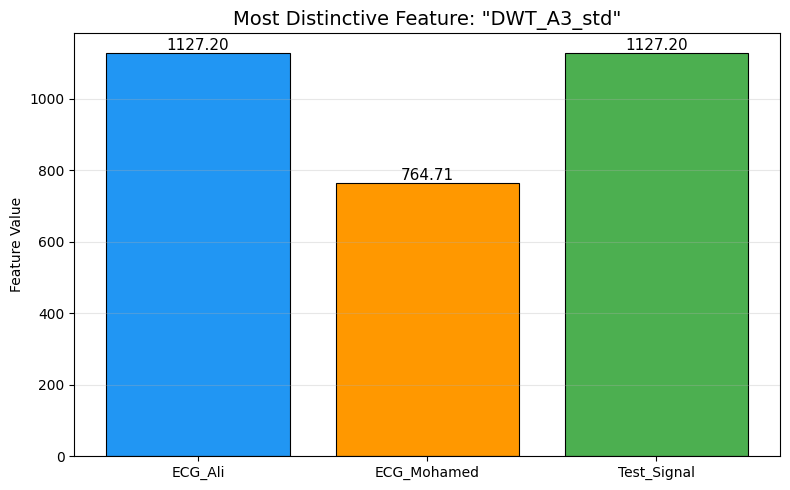

In [20]:
# ── Bar chart comparing the most distinctive feature ─────────────────
labels = ['ECG_Ali', 'ECG_Mohamed', 'Test_Signal']
values = [ali_features[best_feature],
          mohamed_features[best_feature],
          test_features[best_feature]]

colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue, Orange, Green

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
plt.title(f'Most Distinctive Feature: "{best_feature}"', fontsize=14)
plt.ylabel('Feature Value')

# Annotate bars with their values
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

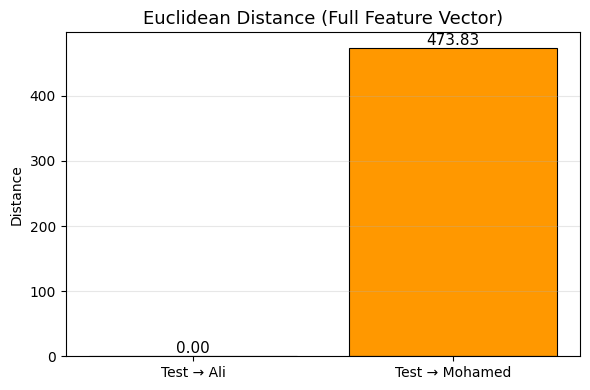

In [21]:
# ── Distance comparison bar chart ────────────────────────────────────
plt.figure(figsize=(6, 4))

dist_labels = ['Test → Ali', 'Test → Mohamed']
dist_values = [eucl_ali, eucl_mohamed]
dist_colors = ['#2196F3', '#FF9800']

bars = plt.bar(dist_labels, dist_values, color=dist_colors,
               edgecolor='black', linewidth=0.8)
plt.title('Euclidean Distance (Full Feature Vector)', fontsize=13)
plt.ylabel('Distance')

for bar, val in zip(bars, dist_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()